In [49]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog
import matplotlib.pyplot as plt
from collections import deque
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
import random
import os
from datetime import datetime
from sklearn.preprocessing import StandardScaler

In [15]:
from pathlib import Path
import copy
import pandas as pd

output_dir = "/Users/lizeyu/Desktop/Quant-on-Crypto/strategies/mmpair-strategy/mmpair-strategy/1m_klines_raw"
output_path = Path(output_dir)

coins_dict = {}

for file in output_path.iterdir():
    if file.is_file() and file.suffix.lower() == ".csv":
        df = pd.read_csv(file, encoding="utf-8")

        df["Close Time"] = df["Close Time"].apply(
            lambda x: x * 1000 + 999 if x < 2000000000000 else x
        )

        df["Close Time"] = pd.to_datetime(df["Close Time"], unit="us")

        df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=False)

        if "Close" not in df.columns or "Close Time" not in df.columns:
            print(f"⚠️ 跳过无 Close 或 Close Time 的文件: {file.name}")
            continue

        df.set_index("Close Time", inplace=True)
        symbol = file.stem.split("_")[0]

        if len(df) == 1140480:
            coins_dict[symbol] = df
            print(f"Processing symbol: {symbol}, length: {len(df)}")


btc = coins_dict["BTCUSDT"]
# chosen = [
#     "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT", "ADAUSDT", "DOGEUSDT", "AVAXUSDT",
#     "LINKUSDT", "TRXUSDT"
#     ]
chosen = [
    "BTCUSDT",
    "ETHUSDT",
    "BNBUSDT",
    "SOLUSDT",
    "XRPUSDT",
    "ADAUSDT",
    "DOGEUSDT",
    "AVAXUSDT",
    "LINKUSDT",
    "TRXUSDT",
    "DOTUSDT",
    "MATICUSDT",
    "LTCUSDT",
    "UNIUSDT",
    "ATOMUSDT",
    "ETCUSDT",
    "ICPUSDT",
    "APTUSDT",
    "FILUSDT",
    "NEARUSDT",
    "HBARUSDT",
    "INJUSDT",
    "OPUSDT",
    "ARBUSDT",
    "SUIUSDT",
    "SEIUSDT",
    "RENDERUSDT",
    "TIAUSDT",
    "FTMUSDT",
    "EGLDUSDT",
    "AAVEUSDT",
    "GALAUSDT",
    "IMXUSDT",
    "PEPEUSDT",
    "SHIBUSDT",
    "FLOKIUSDT",
    "BONKUSDT",
    "WIFUSDT",
    "PENGUUSDT",
    "TRUMPUSDT",
    "POLUSDT",
    "ENSUSDT",
    "JUPUSDT",
    "PYTHUSDT",
    "ORDIUSDT",
    "SATOSHIUSDT",
    "SATSUSDT",
    "MOVRUSDT",
    "DYMUSDT",
    "NOTUSDT",
    "MAGAUSDT",
    "SPXUSDT",
]

HEDGE_LIST = {k: v for k, v in coins_dict.items() if k in chosen}




Processing symbol: IMXUSDT, length: 1140480
Processing symbol: SOLUSDT, length: 1140480
Processing symbol: LTCUSDT, length: 1140480
Processing symbol: SUIUSDT, length: 1140480
Processing symbol: NEARUSDT, length: 1140480
Processing symbol: ATOMUSDT, length: 1140480
Processing symbol: APTUSDT, length: 1140480
Processing symbol: GALAUSDT, length: 1140480
Processing symbol: ARBUSDT, length: 1140480
Processing symbol: TRXUSDT, length: 1140480
Processing symbol: BNBUSDT, length: 1140480
Processing symbol: DOTUSDT, length: 1140480
Processing symbol: FILUSDT, length: 1140480
Processing symbol: ETCUSDT, length: 1140480
Processing symbol: FLOKIUSDT, length: 1140480
Processing symbol: BTCUSDT, length: 1140480
Processing symbol: LINKUSDT, length: 1140480
Processing symbol: SHIBUSDT, length: 1140480
Processing symbol: SEIUSDT, length: 1140480
Processing symbol: MOVRUSDT, length: 1140480
Processing symbol: XRPUSDT, length: 1140480
Processing symbol: PEPEUSDT, length: 1140480
Processing symbol: ADAU

In [16]:
# for name, df in HEDGE_LIST.items():
#     HEDGE_LIST[name] = df.iloc[950000 : ]

# btc = btc.iloc[950000 : ]

In [69]:

FORWARD_WINDOW = 500
BACK_WINDOW = 5000

BULLET_SIZE = 1000
INITIAL = 10000



In [70]:

back_window = BACK_WINDOW
forward_window = FORWARD_WINDOW

In [71]:


btc_close = deque(btc["Close"][:back_window], maxlen=back_window)
coin_closes = {
    name: deque(df["Close"][:back_window], maxlen=back_window)
    for name, df in HEDGE_LIST.items()
}

btc_volume = deque(btc["Volume"][:back_window], maxlen=back_window)
coin_volumes = {
    name: deque(df["Volume"][:back_window], maxlen=back_window)
    for name, df in HEDGE_LIST.items()
}

In [72]:
mkt_idx_1 = deque(np.array([0] * back_window), maxlen=back_window)

xy_1 = {
    name: deque(np.array([0] * back_window), maxlen=back_window)
    for name in HEDGE_LIST.keys()
}
xx_1 = {
    name: deque(np.array([0] * back_window), maxlen=back_window)
    for name in HEDGE_LIST.keys()
}
yy_1 = {
    name: deque(np.array([0] * back_window), maxlen=back_window)
    for name in HEDGE_LIST.keys()
}
x_1 = {
    name: deque(np.array([0] * back_window), maxlen=back_window)
    for name in HEDGE_LIST.keys()
}
y_1 = {
    name: deque(np.array([0] * back_window), maxlen=back_window)
    for name in HEDGE_LIST.keys()
}


xy_1_sum = {name: 0 for name in HEDGE_LIST.keys()}
xx_1_sum = {name: 0 for name in HEDGE_LIST.keys()}
yy_1_sum = {name: 0 for name in HEDGE_LIST.keys()}
x_1_sum = {name: 0 for name in HEDGE_LIST.keys()}
y_1_sum = {name: 0 for name in HEDGE_LIST.keys()}




In [73]:
n = len(HEDGE_LIST.keys())
n

34

In [74]:
    
def model(X, y, X_now):
    reg = LinearRegression().fit(X, y)
    y_pred = reg.predict(X_now)
    corr = np.corrcoef(y, reg.predict(X))[0, 1]
    coefs = reg.coef_
    return y_pred, corr, coefs

# Example usage:
X = np.array([[1,2], [2,3], [3,400]])  # Feature matrix
y = np.array([9,12,12])                # Target vector
X_now = np.array([[1,2]])          # New data point for prediction
y_pred, corr, coefs = model(X, y, X_now)
print(y_pred, corr, coefs)

[9.] 1.0 [ 3.00757576 -0.00757576]


In [75]:
from sklearn.linear_model import Ridge
import numpy as np

def model(X, y, X_now, alpha=1.0):
    # 使用 L2 正则化（Ridge Regression）
    reg = Ridge(alpha=alpha).fit(X, y)
    
    # 预测当前点
    y_pred = reg.predict(X_now)
    
    # 计算相关性（用训练集的拟合）
    corr = np.corrcoef(y, reg.predict(X))[0, 1]
    
    # 模型系数
    coefs = reg.coef_
    
    return y_pred, corr, coefs
# Example usage:
X = np.array([[1,2], [2,3], [3,400]])  # Feature matrix
y = np.array([9,12,12])                # Target vector
X_now = np.array([[1,2]])          # New data point for prediction
y_pred, corr, coefs = model(X, y, X_now)
print(y_pred, corr, coefs)

[9.99999366] 0.8649367962401033 [9.97474828e-01 1.90339629e-05]


In [76]:
# 修改第9个cell，优化内存使用
from collections import deque
import numpy as np
import random
import gc  # 添加垃圾回收

n = len(HEDGE_LIST)
T = len(btc)
time_range = range(back_window+0, T - forward_window)

# --- 1. 初始化窗口结构（O(n)） ---
coin_closes = {name: deque(maxlen=back_window) for name in HEDGE_LIST}
coin_volumes = {name: deque(maxlen=back_window) for name in HEDGE_LIST}

df_closes = {name: df["Close"].to_numpy() for name, df in HEDGE_LIST.items()}
df_volumes = {name: df["Volume"].to_numpy() for name, df in HEDGE_LIST.items()}

Matrix_s = np.zeros((n, back_window))
Matrix_e = np.zeros((n, back_window))
Matrix_y = np.zeros((n, back_window))
Matrix_x1 = np.zeros((n, back_window))
Matrix_x2 = np.zeros((n, back_window))
Matrix_x3 = np.zeros((n, back_window))
Matrix_x4 = np.zeros((n, back_window))

# 协方差累积窗口
xy_1 = {name: deque(maxlen=back_window) for name in HEDGE_LIST}
xx_1 = {name: deque(maxlen=back_window) for name in HEDGE_LIST}
yy_1 = {name: deque(maxlen=back_window) for name in HEDGE_LIST}
x_1  = {name: deque(maxlen=back_window) for name in HEDGE_LIST}
y_1  = {name: deque(maxlen=back_window) for name in HEDGE_LIST}

coin_scores = {coin: deque(maxlen=back_window) for coin in HEDGE_LIST}
# 初始化score
for name in HEDGE_LIST:
    for t in range(back_window):
        coin_scores[name].append(0.5)
cost = 0
costs = []
average_scores = []

xy_1_sum = {name: 0 for name in HEDGE_LIST}
xx_1_sum = {name: 0 for name in HEDGE_LIST}
yy_1_sum = {name: 0 for name in HEDGE_LIST}
x_1_sum  = {name: 0 for name in HEDGE_LIST}
y_1_sum  = {name: 0 for name in HEDGE_LIST}

# 限制列表大小，防止无限增长
MAX_HISTORY = 1000000  # 最多保存10000个历史记录
revenues = deque(maxlen=MAX_HISTORY)
corrs = deque(maxlen=MAX_HISTORY)
coef1s = deque(maxlen=MAX_HISTORY)
coef2s = deque(maxlen=MAX_HISTORY)
coin_1_names = deque(maxlen=MAX_HISTORY)
coin_2_names = deque(maxlen=MAX_HISTORY)
differences = deque(maxlen=MAX_HISTORY)
revenues_1 = deque(maxlen=MAX_HISTORY)
revenues_2 = deque(maxlen=MAX_HISTORY)
each_revenue = deque(maxlen=MAX_HISTORY)

# 添加coef历史记录和BTC价格记录
coef_history = []
coef_timestamps = deque(maxlen=MAX_HISTORY)
btc_price_history = deque(maxlen=MAX_HISTORY)

revenue = 0
revenue_1 = 0
revenue_2 = 0

mkt_idx_1 = deque(maxlen=back_window)  # 限制大小

# 随机选择一个 row（币种）
random_row = np.random.randint(0, n)
col_sums = np.zeros(back_window)
col_sumsq = np.zeros(back_window)
count = 0

# --- 生成权重矩阵 ---
weights = np.ones(back_window)

# 后 fw 列加权
for i in range(back_window - forward_window, back_window):
    weights[i] = np.sqrt((forward_window) / (back_window - i + 1e-12))

# 预分配数组，避免重复创建
coin_names = list(HEDGE_LIST.keys())

for step, t in tqdm(enumerate(time_range), total=len(time_range)):

    # --- 1）更新 close O(1) ---
    for name in HEDGE_LIST:
        close_t = df_closes[name][t]
        coin_closes[name].append(close_t)
        volume_t = df_volumes[name][t]
        coin_volumes[name].append(volume_t)


    # --- 2）构造 Matrix_s（O(n·window） ---
    Matrix_s[:, :-1] = Matrix_s[:, 1:]  # 向量化操作
    for i_coin, name in enumerate(HEDGE_LIST):
        Matrix_s[i_coin, -1] = df_closes[name][t]

    # --- 3）构造 Matrix_e（O(n·window） ---
    for i_coin, name in enumerate(HEDGE_LIST):
        prices = df_closes[name]
        last_close = prices[t]
        
        start = max(0, t - back_window + forward_window)  # 防止负索引
        end_future = t 
        
        fw = prices[start:end_future]
        L = len(fw)
        
        if L >= back_window:
            Matrix_e[i_coin, :] = fw[-back_window:]  # 取最后back_window个
        else:
            Matrix_e[i_coin, :L] = fw
            Matrix_e[i_coin, L:] = last_close

    # --- 4）构造 Matrix_x1 ---
    for i_coin, name in enumerate(HEDGE_LIST):
        prices_array = np.array(coin_closes[name])
        
        if len(prices_array) < 2:
            cmi = 0
        else:
            diff = np.diff(prices_array)
            abs_diff_sum = np.sum(np.abs(diff))
            
            if abs_diff_sum < 1e-12:
                cmi = 0
            else:
                cmi = ((prices_array[-1] - prices_array[0]) / abs_diff_sum) * 100
                
        if np.isnan(cmi) or np.isinf(cmi):
            cmi = 0
            
        Matrix_x1[i_coin, :-1] = Matrix_x1[i_coin, 1:]
        Matrix_x1[i_coin, -1] = cmi

    # --- 5）计算 Matrix_x2 ---
    for i_coin, name in enumerate(HEDGE_LIST):
        prices = np.array(coin_closes[name])
        
        if len(prices) < 2:
            zsc = 0
        else:
            mean_price = np.mean(prices)
            std_price = np.std(prices)
            
            if std_price < 1e-12:
                zsc = 0
            else:
                zsc = (prices[-1] - mean_price) / std_price
                
        if np.isnan(zsc) or np.isinf(zsc):
            zsc = 0
            
        Matrix_x2[i_coin, :-1] = Matrix_x2[i_coin, 1:]
        Matrix_x2[i_coin, -1] = zsc
    
    for i_coin, name in enumerate(HEDGE_LIST):
        prices = np.array(coin_closes[name])
        volumes = np.array(coin_volumes[name])

        first_quarter_price = np.mean(prices[: back_window // 4])
        first_quarter_volume = np.mean(volumes[: back_window // 4])
        fourth_quarter_price = np.mean(prices[3 * back_window // 4 :])
        fourth_quarter_volume = np.mean(volumes[3 * back_window // 4 :])
        sl_price = (fourth_quarter_price - first_quarter_price) / (first_quarter_price + 1e-12) * 100
        sl_volume = (fourth_quarter_volume - first_quarter_volume) / (first_quarter_volume + 1e-12) * 100
        sl = sl_price * sl_volume

        Matrix_x3[i_coin, :-1] = Matrix_x3[i_coin, 1:]
        Matrix_x3[i_coin, -1] = sl

    for i_coin, name in enumerate(HEDGE_LIST):
        prices = np.array(coin_closes[name])
        volumes = np.array(coin_volumes[name])

        first_half_price = np.mean(prices[: back_window // 2])
        first_half_volume = np.mean(volumes[: back_window // 2])
        fourth_half_price = np.mean(prices[1 * back_window // 2 :])
        fourth_half_volume = np.mean(volumes[1 * back_window // 2 :])
        sl_price = (fourth_quarter_price - first_quarter_price) / (first_quarter_price + 1e-12) * 100
        sl_volume = (fourth_quarter_volume - first_quarter_volume) / (first_quarter_volume + 1e-12) * 100
        sl = sl_price * sl_volume

        Matrix_x4[i_coin, :-1] = Matrix_x4[i_coin, 1:]
        Matrix_x4[i_coin, -1] = sl


    # 1. 计算 Matrix_y - 向量化操作
    Matrix_s_safe = np.where(np.abs(Matrix_s) < 1e-12, 1e-12, Matrix_s)
    Matrix_y = (Matrix_e - Matrix_s) / Matrix_s_safe
    Matrix_y = np.where(np.isnan(Matrix_y) | np.isinf(Matrix_y), 0, Matrix_y)
    Matrix_y = Matrix_y * weights

    if step > back_window:
        y_row = Matrix_y[random_row, :]
        col_sums += y_row
        col_sumsq += y_row * y_row
        count += 1

    # --- 4）相关性/系数计算（O(1)） ---
    mkt_idx_1.append(btc["Close"].iloc[t])

    if len(mkt_idx_1) >= 2:
        mkt_idx_1_diff = mkt_idx_1[-1] - mkt_idx_1[-2]
    else:
        continue

    for name in HEDGE_LIST:
        closes = coin_closes[name]

        if len(closes) < 2:
            continue

        growth = closes[-1] - closes[-2]

        old_xy = xy_1[name][0] if len(xy_1[name]) == back_window else 0
        old_xx = xx_1[name][0] if len(xx_1[name]) == back_window else 0
        old_yy = yy_1[name][0] if len(yy_1[name]) == back_window else 0

        xy_1[name].append(growth * mkt_idx_1_diff)
        xx_1[name].append(mkt_idx_1_diff**2)
        yy_1[name].append(growth**2)

        xy_1_sum[name] += xy_1[name][-1] - old_xy
        xx_1_sum[name] += xx_1[name][-1] - old_xx
        yy_1_sum[name] += yy_1[name][-1] - old_yy

    # --- 5）策略区（满窗口后开始） ---
    if step >= 2 * back_window and step % 1 == 0:
        coef_timestamps.append(step)
        btc_price_history.append(btc["Close"].iloc[t])



        # 预分配数组，避免重复创建
        x_1_now = Matrix_x1[:, -1]
        x_2_now = Matrix_x2[:, -1]

        y_flat = Matrix_y[:, :-1].flatten()
        x_1_flat = Matrix_x1[:, :-1].flatten()
        x_2_flat = Matrix_x2[:, :-1].flatten()

        x_3_now = Matrix_x3[:, -1]
        x_4_now = Matrix_x4[:, -1]

        y_flat = Matrix_y[:, :-1].flatten()
        x_3_flat = Matrix_x3[:, :-1].flatten()
        x_4_flat = Matrix_x4[:, :-1].flatten()

        # X_p_now = np.column_stack([x_1_now, x_2_now, x_3_now, x_4_now])
        # X_p = np.column_stack([x_1_flat, x_2_flat, x_3_flat, x_4_flat])
        # X_n_now = np.column_stack([x_1_now, x_2_now, x_3_now, x_4_now])
        # X_n = np.column_stack([x_1_flat, x_2_flat, x_3_flat, x_4_flat])

        X_p_now = np.column_stack([x_1_now, x_3_now])
        X_p = np.column_stack([x_1_flat, x_3_flat])
        X_n_now = np.column_stack([x_1_now, x_3_now])
        X_n = np.column_stack([x_1_flat, x_3_flat])
        # if step%1000==0:
        #     print(f"Step {step}: X_p: {X_p}, X_n: {X_n}, y_flat: {y_flat}")
        
        data_is_valid = (
            not np.any(np.isnan(X_n)) and not np.any(np.isinf(X_n)) and
            not np.any(np.isnan(X_p)) and not np.any(np.isinf(X_p)) and
            not np.any(np.isnan(y_flat)) and not np.any(np.isinf(y_flat)) and
            not np.any(np.isnan(X_p_now)) and not np.any(np.isinf(X_p_now)) and
            not np.any(np.isnan(X_n_now)) and not np.any(np.isinf(X_n_now))
        )

        # 检查数据有效性
        if data_is_valid:

            try:

                # ===== 1）创建 scaler =====
                scaler = StandardScaler()

                # ===== 2）fit-transform 训练集 =====
                X_p_scaled = scaler.fit_transform(X_p)

                # ===== 3）transform 当前样本 =====
                X_p_now_scaled = scaler.transform(X_p_now)

                # ===== 4）送入你的模型 =====
                y_p_pred, corr, coefs = model(X_p_scaled, y_flat, X_p_now_scaled)
                # y_n_pred, corr, coefs= model(X_n, y_flat, X_n_now)
                y_n_pred = y_p_pred

                if np.any(np.isnan(y_p_pred)) or np.any(np.isinf(y_p_pred)) or np.any(np.isnan(y_n_pred)) or np.any(np.isinf(y_n_pred)):
                    continue
                    
                if np.isnan(corr) or np.isinf(corr):
                    corr = 0
                    
            except Exception:
                print(f"Step {step}: Model fitting failed.")
                continue
        else:
            print(f"Step {step}: Invalid data encountered.")
            continue

        # 计算系数
        coef = {}
        for name in HEDGE_LIST:
            if abs(xx_1_sum[name]) > 1e-12:
                coef[name] = (xy_1_sum[name] / xx_1_sum[name]) * 1000
            else:
                coef[name] = 0

        # 选择币种
        # max_y_idx = np.argmax(y_p_pred) % len(coin_names)
        # min_y_idx = np.argmin(y_n_pred) % len(coin_names)

        max_y_idx = np.argmax(y_p_pred) 
        min_y_idx = np.argmin(y_n_pred) 

        coin_1 = coin_names[max_y_idx]
        coin_2 = coin_names[min_y_idx]

        c1_coef = coef[coin_1]
        c2_coef = coef[coin_2]

        # coef1, coef2 = coefs[0], coefs[1]
        difference = y_p_pred[max_y_idx] - y_p_pred[min_y_idx]

        p1_now = coin_closes[coin_1][-1]
        p2_now = coin_closes[coin_2][-1]

        denom = c1_coef * p2_now + c2_coef * p1_now
        if abs(denom) < 1e-12:
            continue

        n1 = BULLET_SIZE * c2_coef / denom
        n2 = -BULLET_SIZE * c1_coef / denom

        r1 = n1 * (df_closes[coin_1][t + forward_window] - p1_now)
        r2 = n2 * (df_closes[coin_2][t + forward_window] - p2_now)

        r1 = np.clip(r1, -10, 10)  # 更高效的裁剪
        r2 = np.clip(r2, -10, 10)

        revenue_now = r1 + r2


        temp_1 = coin_scores[coin_1][-1]
        temp_2 = coin_scores[coin_2][-1]

        if r1 > 5:
            coin_scores[coin_1].append(min(temp_1 / 0.8, 1))
        elif r1 < -5:
            coin_scores[coin_1].append(max(temp_1 * 0.8, 0.05))
        else:
            coin_scores[coin_1].append(temp_1)

        if r2 > 5:
            coin_scores[coin_2].append(min(temp_2 / 0.8, 1))
        elif r2 < -5:
            coin_scores[coin_2].append(max(temp_2 * 0.8, 0.05))
        else:
            coin_scores[coin_2].append(temp_2)

        coef_history.append([coefs])  # 保存当前系数向量

        norm = min(coin_scores[coin_1][0], coin_scores[coin_2][0])
        revenue += revenue_now*norm
        cost += BULLET_SIZE*norm*0.001
        costs.append(cost)


        average_score = np.mean([coin_scores[coin][0] for coin in HEDGE_LIST])
        average_scores.append(average_score)


        revenue_1 += r1*norm
        revenue_2 += r2*norm

        each_revenue.append(revenue_now)
        revenues.append(revenue)
        corrs.append(corr)
        # coef1s.append(coef1)
        # coef2s.append(coef2)
        coin_1_names.append(coin_1)
        coin_2_names.append(coin_2)
        differences.append(difference)
        revenues_1.append(revenue_1)
        revenues_2.append(revenue_2)
    if step % 1000 == 0:

        fig, axes = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[1, 1.2])

        # ======================================================
        #  上图 —— 收益曲线（保持你原来左上角的内容）
        # ======================================================
        ax_revenue = axes[0]


        # 收益曲线
        ax_revenue.set_xlabel("Steps")
        ax_revenue.set_ylabel("Revenue", color='black')
        ax_revenue.plot(list(revenues), label="Total Revenue", color="blue", linewidth=2)
        ax_revenue.plot(list(revenues_1), label="Revenue Coin 1", color="orange", linewidth=2)
        ax_revenue.plot(list(revenues_2), label="Revenue Coin 2", color="green", linewidth=2)
        ax_revenue.tick_params(axis='y', labelcolor='black')
        ax_revenue.grid(True, alpha=0.3)

        # 分数（右轴）
        ax_scores = ax_revenue.twinx()
        ax_scores.set_ylabel("Scores", color='yellow')
        ax_scores.plot(list(average_scores), label="Average Scores",
                        color="yellow", linewidth=2, alpha=0.8, linestyle='--')
        ax_scores.tick_params(axis='y', labelcolor='yellow')

        ax_revenue.set_title("Revenue and Scores Over Time")

        # 合并 legend
        lines1, labels1 = ax_revenue.get_legend_handles_labels()
        lines2, labels2 = ax_scores.get_legend_handles_labels()
        ax_revenue.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
        # ======================================================
        #  下图 —— BTC（左轴） + coef（右轴）
        # ======================================================
        ax_btc = axes[1]            # 主轴：BTC
        ax_coef = ax_btc.twinx()    # 次轴：coef

        # ---------- BTC ----------
        if len(btc_price_history) > 0:
            ax_btc.plot(
                list(coef_timestamps),
                list(btc_price_history),
                label="BTC Price",
                linewidth=2
            )

        ax_btc.set_ylabel("BTC Price (USDT)")
        ax_btc.grid(True, alpha=0.3)

        # ---------- coef (4维) ----------
        if len(coef_history) > 0:
            coef_arr = np.array(coef_history).reshape(-1, 2)  # (T,4)

            for i in range(2):
                ax_coef.plot(
                    list(coef_timestamps),
                    coef_arr[:, i],
                    linewidth=1.2,
                    alpha=0.9,
                    label=f"coef[{i}]"
                )

        ax_coef.set_ylabel("Coefficient Values")

        # ---------- legend 合并 ----------
        lines1, labels1 = ax_btc.get_legend_handles_labels()
        lines2, labels2 = ax_coef.get_legend_handles_labels()
        ax_btc.legend(lines1 + lines2, labels1 + labels2,
                    loc="upper left", fontsize=10)

        ax_btc.set_title("BTC Price & Model Coefficients Over Time")
        ax_btc.set_xlabel("Steps")

        # ======================================================
        plt.tight_layout()
        plt.savefig("comprehensive_analysis.png", dpi=120, bbox_inches='tight')













        # 保存数据
        indicators_and_each_revenue = pd.DataFrame({
            "Correlation": list(corrs),
            # "Coef1": list(coef1s),
            # "Coef2": list(coef2s),
            "coin_1": list(coin_1_names),
            "coin_2": list(coin_2_names),
            "Difference": list(differences),
            "Each Revenue": list(each_revenue)
        })
        indicators_and_each_revenue.to_csv("indicators_and_each_revenue.csv", index=False)
        plt.close()
        

    # 每10000步清理一次内存
    if step % 10000 == 0:
        gc.collect()

  0%|          | 0/184980 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
 23%|██▎       | 42757/184980 [34:37<1:55:11, 20.58it/s] 


KeyboardInterrupt: 

In [ ]:
coef_arr

array([[[-4.02601554e-04, -7.79539898e-03,  2.88785475e-07,
          2.07749689e-05]]])

In [ ]:
car = pd.read_csv("indicators_and_each_revenue.csv")
car

,Correlation,coin_1,coin_2,Difference,Each Revenue
0,0.591340,AVAXUSDT,AAVEUSDT,0.014762,0.000000
1,0.584608,AVAXUSDT,AAVEUSDT,0.014644,0.000000
2,0.589601,AVAXUSDT,AAVEUSDT,0.015283,0.000000
3,0.587264,AVAXUSDT,AAVEUSDT,0.015290,0.000000
4,0.588330,AVAXUSDT,AAVEUSDT,0.015054,0.000000
...,...,...,...,...,...
186996,0.489424,UNIUSDT,SEIUSDT,0.018972,4.135497
186997,0.485676,UNIUSDT,SEIUSDT,0.018412,4.139442
186998,0.479699,UNIUSDT,SEIUSDT,0.018089,4.734340
186999,0.471822,UNIUSDT,SEIUSDT,0.017876,3.470389


原始数据形状: (187001, 5)

去除极值前的数据统计:
Correlation: 范围 [0.022301, 0.832881], 均值 0.366455
Difference: 范围 [0.000051, 0.760535], 均值 0.011031
Each Revenue: 范围 [-20.000000, 20.000000], 均值 0.104546
Correlation: 移除了 186 个极值
Difference: 移除了 6761 个极值
Each Revenue: 移除了 9359 个极值

去除极值后数据形状: (177642, 5)
移除了 9359 个数据点 (5.00%)

去除极值后的数据统计:
Correlation: 范围 [0.022301, 0.779139], 均值 0.364692
Difference: 范围 [0.000051, 0.028275], 均值 0.009557
Each Revenue: 范围 [-11.493574, 11.793812], 均值 0.132569


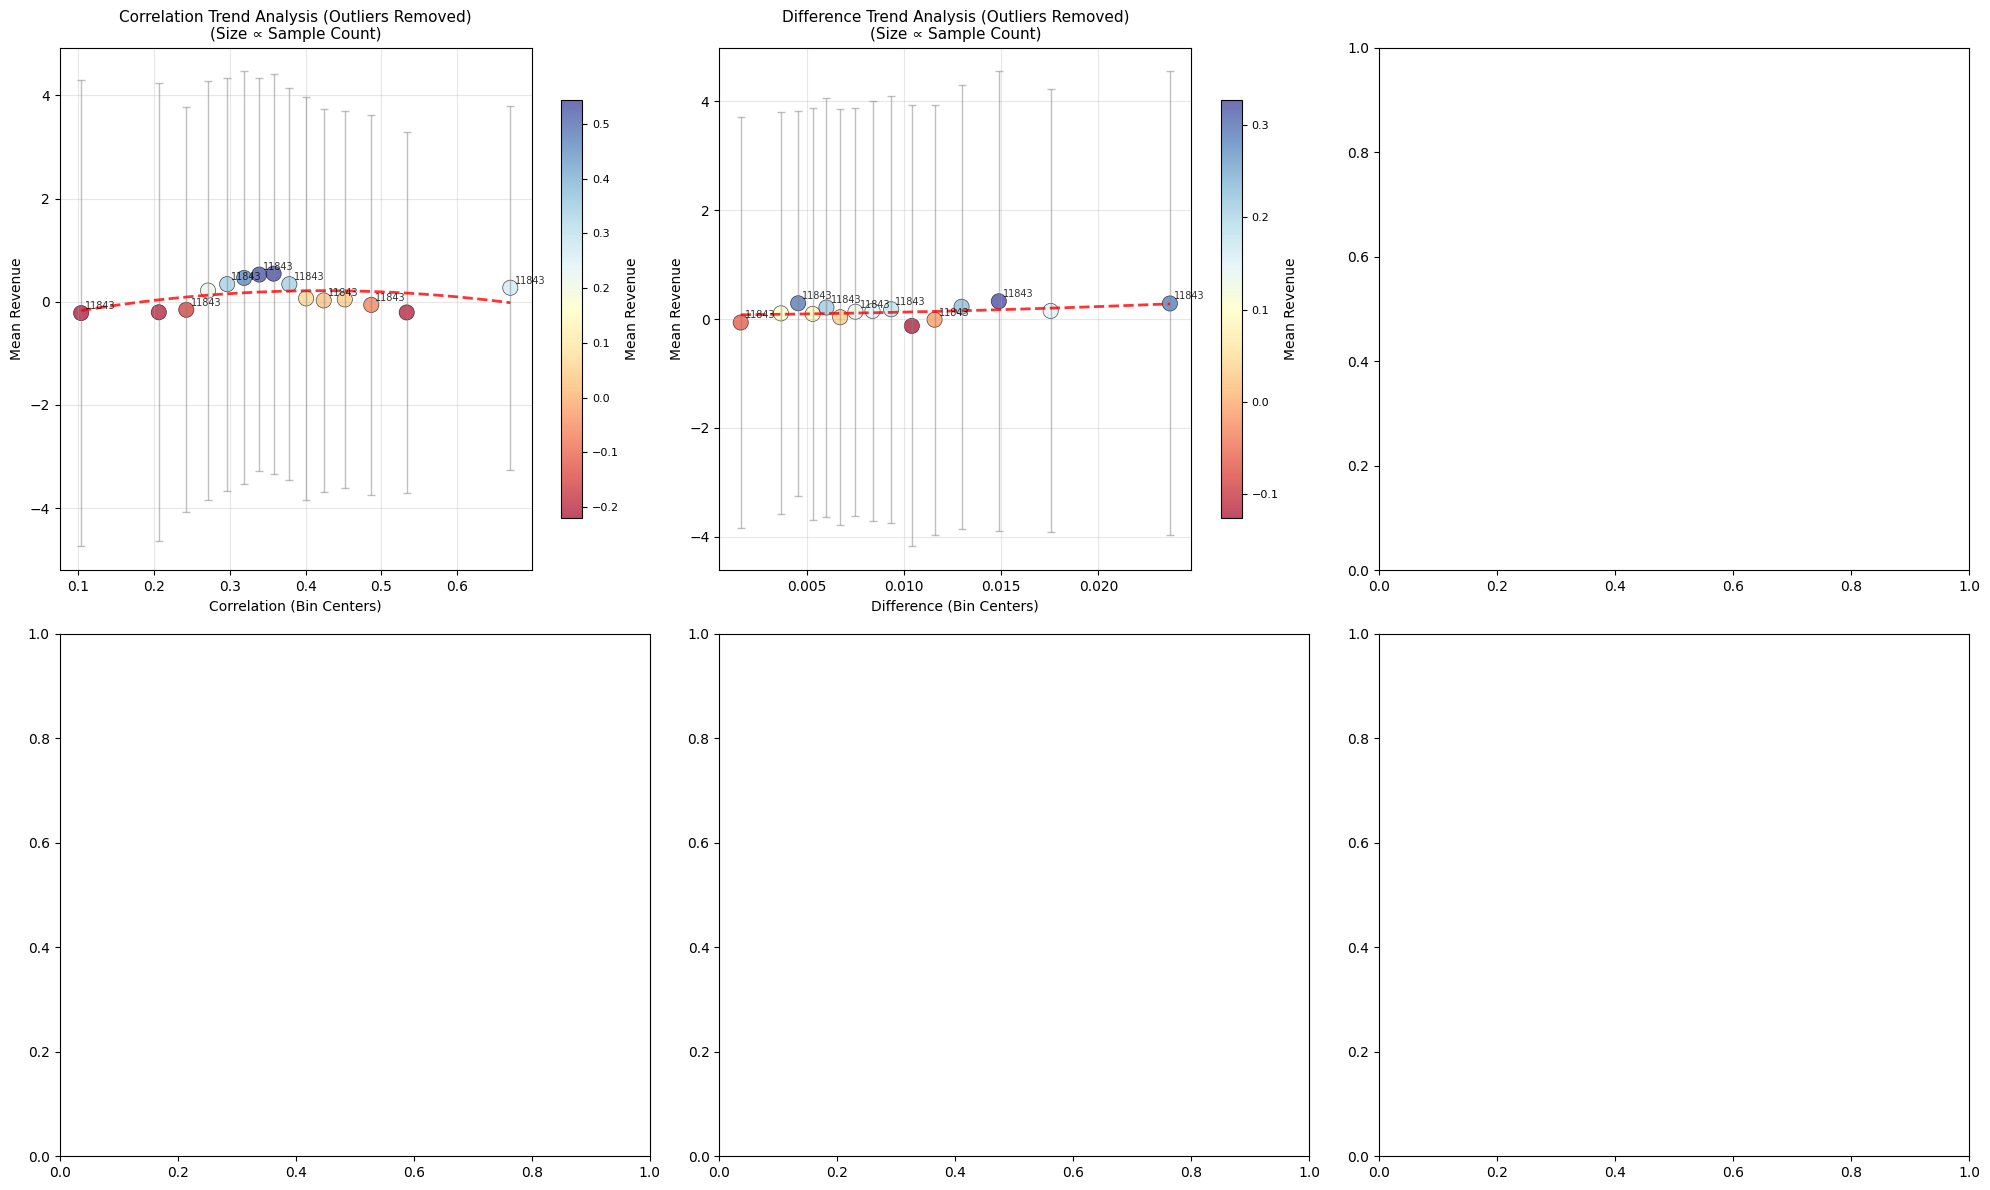


去除极值后的相关性分析:
Correlation          vs Each Revenue: 0.0097
Difference           vs Each Revenue: 0.0119


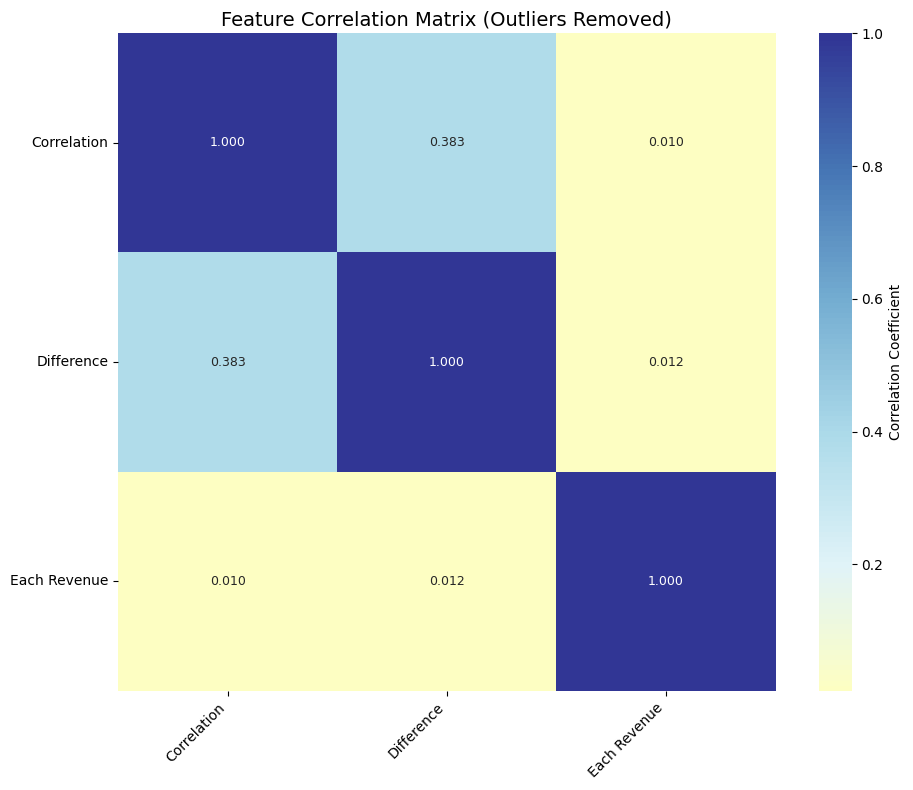


去除极值后的币种收益分析:
作为 coin_1 (多头) 的前10名:
    Coin  Count  Mean_Revenue  Std_Revenue
 ICPUSDT   2204      1.641887     3.685483
HBARUSDT   4954      1.029172     4.337375
 SOLUSDT   5421      0.829329     3.669844
GALAUSDT    869      0.699456     3.724512
 DOTUSDT   1148      0.586307     2.934315
 SEIUSDT   8598      0.452709     4.323120
LINKUSDT   4851      0.401914     4.293737
 UNIUSDT   6856      0.375146     4.294594
 INJUSDT   5779      0.310869     3.895078
 TRXUSDT  21089      0.277535     3.364927

作为 coin_2 (空头) 的前10名:
     Coin  Count  Mean_Revenue  Std_Revenue
  FILUSDT   2472      0.881900     3.300169
 MOVRUSDT   6848      0.871747     3.784124
  ICPUSDT   1698      0.866442     3.363453
  ETCUSDT   2122      0.759276     4.230739
 GALAUSDT   1544      0.663956     3.496180
FLOKIUSDT   3771      0.642298     4.696500
  SUIUSDT   4343      0.588013     4.361678
  INJUSDT   3231      0.543912     3.908439
 SHIBUSDT   1924      0.458162     3.227145
  SEIUSDT   4123      0.438

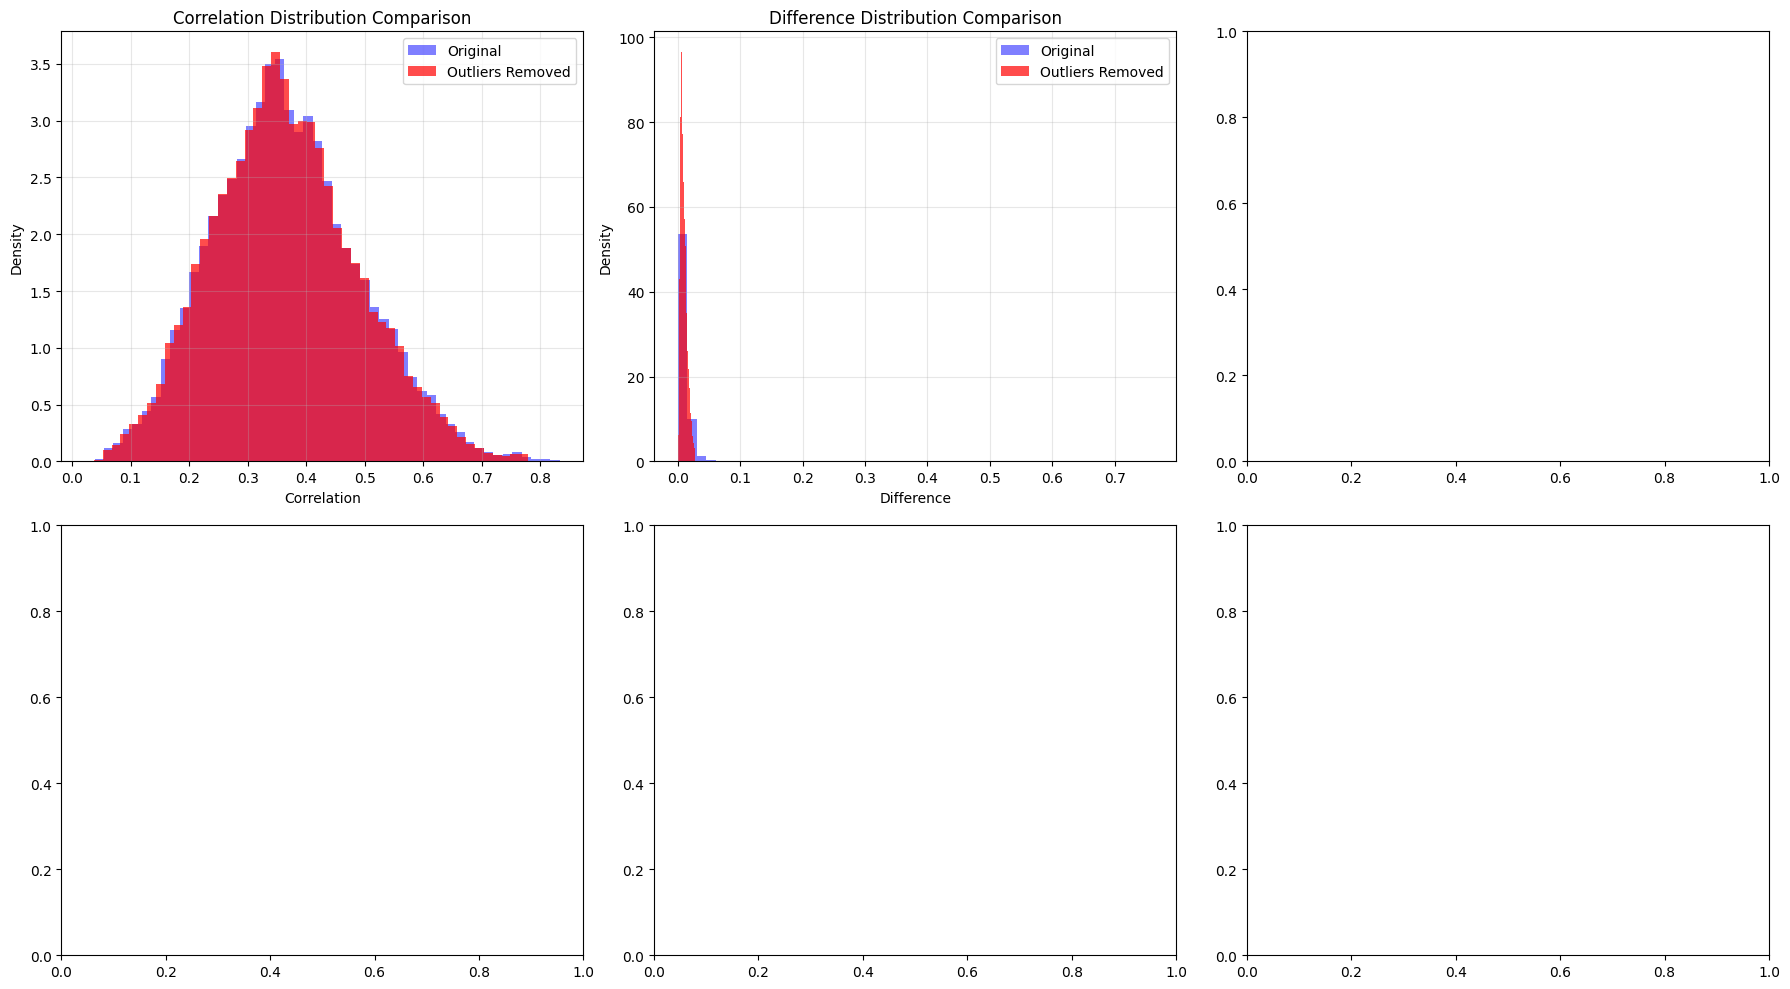


清理后的数据已保存为 'indicators_and_each_revenue_no_outliers.csv'


In [ ]:
# 去掉极值的数据预处理和分析
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 重新加载数据
car = pd.read_csv("indicators_and_each_revenue.csv")
print("原始数据形状:", car.shape)

# # 创建新的特征
# car['Coef1_plus_Coef2'] = car['Coef1'] + car['Coef2']
# car['Coef1_minus_Coef2'] = car['Coef1'] - car['Coef2']

# 扩展数值列
# numerical_cols = ['Correlation', 'Coef1', 'Coef2', 'Difference', 'Coef1_plus_Coef2', 'Coef1_minus_Coef2', 'Each Revenue']
numerical_cols = ['Correlation',  'Difference',  'Each Revenue']

print("\n去除极值前的数据统计:")
for col in numerical_cols:
    print(f"{col}: 范围 [{car[col].min():.6f}, {car[col].max():.6f}], 均值 {car[col].mean():.6f}")

# 去除极值函数
def remove_outliers(df, columns, method='iqr', factor=1.5):
    """
    去除极值
    method: 'iqr' 使用IQR方法, 'zscore' 使用Z分数方法
    factor: IQR方法的倍数因子，或Z分数的阈值
    """
    df_clean = df.copy()
    
    for col in columns:
        if method == 'iqr':
            # IQR方法
            Q1 = df_clean[col].quantile(0.25)
            Q3 = df_clean[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - factor * IQR
            upper_bound = Q3 + factor * IQR
        elif method == 'zscore':
            # Z分数方法
            mean = df_clean[col].mean()
            std = df_clean[col].std()
            lower_bound = mean - factor * std
            upper_bound = mean + factor * std
        elif method == 'percentile':
            # 百分位数方法
            lower_bound = df_clean[col].quantile(0.01)
            upper_bound = df_clean[col].quantile(0.99)
        
        # 过滤极值
        mask = (df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)
        df_clean = df_clean[mask]
        
        print(f"{col}: 移除了 {len(df) - len(df_clean)} 个极值")
    
    return df_clean

# 使用IQR方法去除极值 (可以尝试不同的factor值)
car_clean = remove_outliers(car, numerical_cols, method='iqr', factor=2.0)
print(f"\n去除极值后数据形状: {car_clean.shape}")
print(f"移除了 {len(car) - len(car_clean)} 个数据点 ({(len(car) - len(car_clean))/len(car)*100:.2f}%)")

print("\n去除极值后的数据统计:")
for col in numerical_cols:
    print(f"{col}: 范围 [{car_clean[col].min():.6f}, {car_clean[col].max():.6f}], 均值 {car_clean[col].mean():.6f}")

# 更新数值列（去除Each Revenue）
# analysis_cols = ['Correlation', 'Coef1', 'Coef2', 'Difference', 'Coef1_plus_Coef2', 'Coef1_minus_Coef2']
analysis_cols = ['Correlation', 'Difference']
y = car_clean['Each Revenue'].values

# 趋势分析 - 使用清理后的数据
n_bins = 15

# 创建趋势分析图
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, col in enumerate(analysis_cols):
    ax = axes[idx]
    
    # 创建分箱
    x = car_clean[col].values
    bins = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    car_clean[f'{col}_Bin'] = pd.cut(car_clean[col], bins=bins, labels=False, include_lowest=True)
    
    bin_stats = car_clean.groupby(f'{col}_Bin')['Each Revenue'].agg(['mean', 'std', 'count']).reset_index()
    
    # 计算分箱中心点
    bin_centers = []
    means = []
    stds = []
    counts = []
    
    for i, row in bin_stats.iterrows():
        if row['count'] > 10:  # 只显示样本数大于10的分箱
            bin_idx = int(row[f'{col}_Bin'])
            center = (bins[bin_idx] + bins[bin_idx + 1]) / 2
            bin_centers.append(center)
            means.append(row['mean'])
            stds.append(row['std'])
            counts.append(row['count'])
    
    if len(bin_centers) > 0:
        # 调整散点大小
        max_count = max(counts)
        min_size = 30   # 最小点大小
        max_size = 120  # 最大点大小
        sizes = [min_size + (count/max_count) * (max_size - min_size) for count in counts]
        
        # 绘制趋势线
        scatter = ax.scatter(bin_centers, means, s=sizes, 
                           alpha=0.7, c=means, cmap='RdYlBu', edgecolors='black', linewidths=0.5)
        
        # 添加误差棒
        ax.errorbar(bin_centers, means, yerr=stds, fmt='none', 
                   color='gray', alpha=0.5, capsize=3, linewidth=1)
        
        # 添加拟合线
        if len(bin_centers) > 2:
            z = np.polyfit(bin_centers, means, min(2, len(bin_centers)-1))
            p = np.poly1d(z)
            x_smooth = np.linspace(min(bin_centers), max(bin_centers), 100)
            ax.plot(x_smooth, p(x_smooth), '--', alpha=0.8, color='red', linewidth=2)
        
        # 设置标签和标题
        ax.set_xlabel(f'{col} (Bin Centers)', fontsize=10)
        ax.set_ylabel('Mean Revenue', fontsize=10)
        ax.set_title(f'{col} Trend Analysis (Outliers Removed)\n(Size ∝ Sample Count)', fontsize=11)
        ax.grid(True, alpha=0.3)
        
        # 添加颜色条
        cbar = plt.colorbar(scatter, ax=ax, label='Mean Revenue', shrink=0.8)
        cbar.ax.tick_params(labelsize=8)
        
        # 标注样本数
        for i, (x_pos, y_pos, count) in enumerate(zip(bin_centers, means, counts)):
            if i % 2 == 0:
                ax.annotate(f'{int(count)}', (x_pos, y_pos), xytext=(3, 3), 
                           textcoords='offset points', fontsize=7, alpha=0.8)

plt.tight_layout()
plt.savefig('trend_analysis_no_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# 相关性分析 - 使用清理后的数据
print("\n" + "=" * 80)
print("去除极值后的相关性分析:")
print("=" * 80)
for col in analysis_cols:
    corr = np.corrcoef(car_clean[col].values, car_clean['Each Revenue'].values)[0, 1]
    print(f"{col:<20} vs Each Revenue: {corr:.4f}")

# 相关性矩阵可视化
plt.figure(figsize=(10, 8))
correlation_matrix = car_clean[analysis_cols + ['Each Revenue']].corr()

sns.heatmap(correlation_matrix, 
           annot=True, 
           cmap='RdYlBu', 
           center=0,
           square=True, 
           fmt='.3f', 
           cbar_kws={'label': 'Correlation Coefficient'},
           annot_kws={'size': 9})

plt.title('Feature Correlation Matrix (Outliers Removed)', fontsize=14)
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('correlation_matrix_no_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# 币种收益分析 - 使用清理后的数据
print("\n" + "=" * 80)
print("去除极值后的币种收益分析:")
print("=" * 80)

# coin_1 收益分析
coin_1_revenue = car_clean.groupby('coin_1')['Each Revenue'].agg(['count', 'mean', 'std']).reset_index()
coin_1_revenue.columns = ['Coin', 'Count', 'Mean_Revenue', 'Std_Revenue']
coin_1_revenue = coin_1_revenue.sort_values('Mean_Revenue', ascending=False)

print("作为 coin_1 (多头) 的前10名:")
print(coin_1_revenue.head(10).to_string(index=False))

# coin_2 收益分析  
coin_2_revenue = car_clean.groupby('coin_2')['Each Revenue'].agg(['count', 'mean', 'std']).reset_index()
coin_2_revenue.columns = ['Coin', 'Count', 'Mean_Revenue', 'Std_Revenue']
coin_2_revenue = coin_2_revenue.sort_values('Mean_Revenue', ascending=False)

print("\n作为 coin_2 (空头) 的前10名:")
print(coin_2_revenue.head(10).to_string(index=False))

# 对比去极值前后的数据分布
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(analysis_cols):
    ax = axes[idx]
    
    # 绘制直方图对比
    ax.hist(car[col], bins=50, alpha=0.5, label='Original', color='blue', density=True)
    ax.hist(car_clean[col], bins=50, alpha=0.7, label='Outliers Removed', color='red', density=True)
    
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.set_title(f'{col} Distribution Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 保存清理后的数据
car_clean.to_csv('indicators_and_each_revenue_no_outliers.csv', index=False)
print(f"\n清理后的数据已保存为 'indicators_and_each_revenue_no_outliers.csv'")

/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_3471/4171519577.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coin_revenue['Adjusted Revenue'] = coin_revenue.apply(
/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_3471/4171519577.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coin_revenue['Adjusted Revenue'] = coin_revenue.apply(
/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_3471/4171519577.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy o

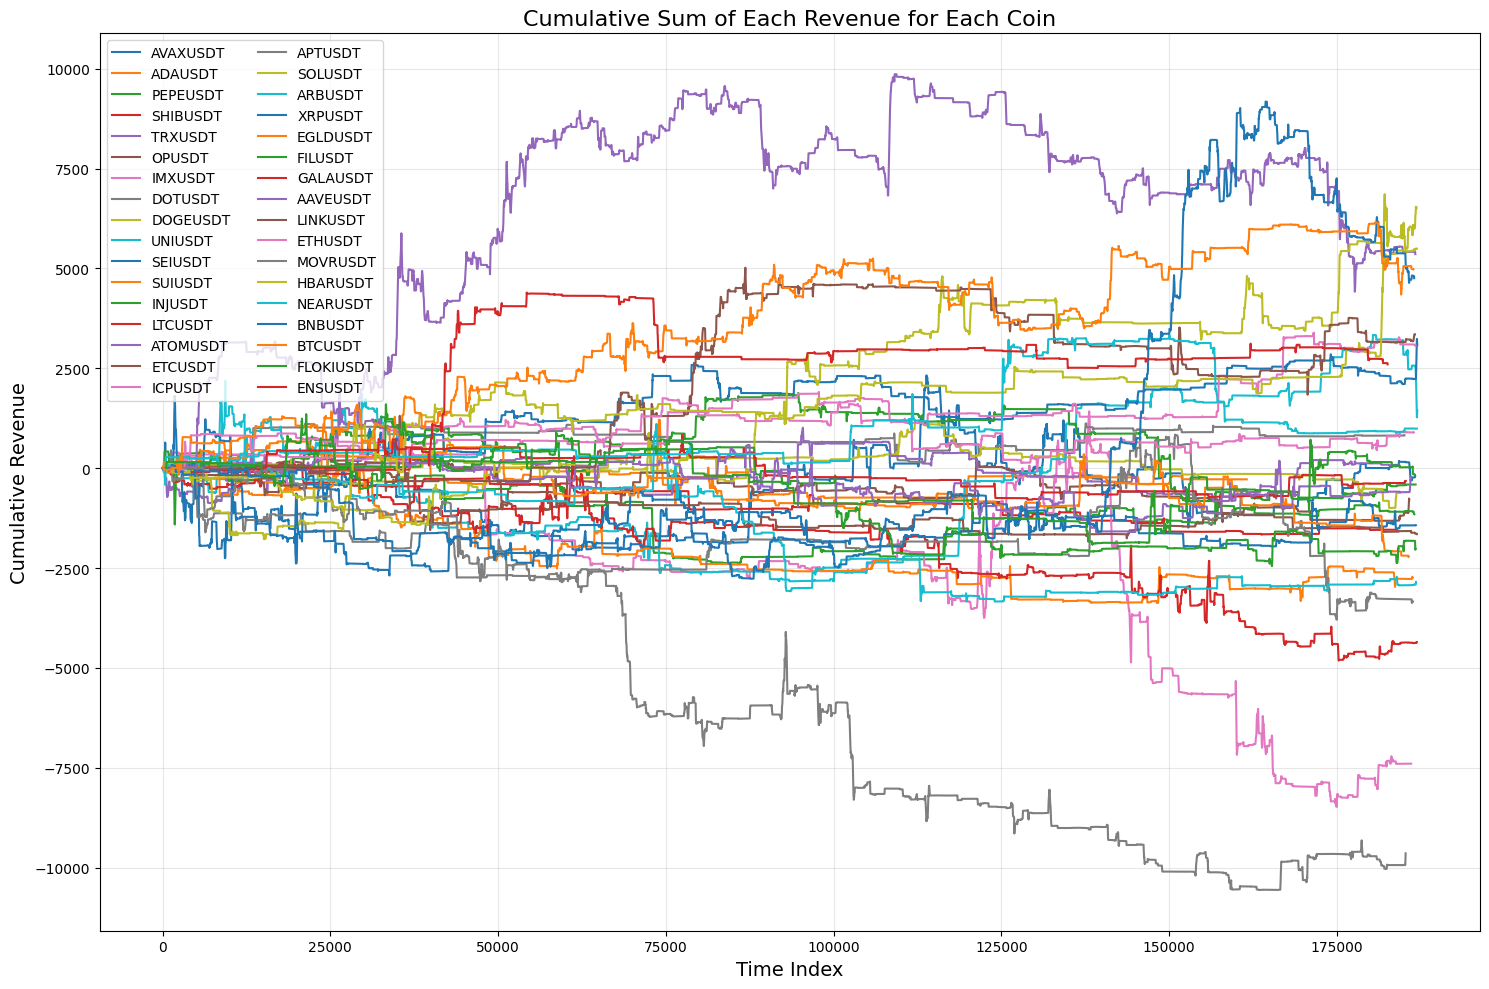

In [ ]:
import matplotlib.pyplot as plt

# 获取所有唯一的 Coin
unique_coins = pd.concat([car['coin_1'], car['coin_2']]).unique()

# 初始化一个字典存储每个 Coin 的 cumsum
coin_cumsum = {}

# 计算每个 Coin 的 cumsum
for coin in unique_coins:
  # 筛选 coin_1 和 coin_2 中包含当前 coin 的行
  coin_revenue = car[(car['coin_1'] == coin) | (car['coin_2'] == coin)]
  
  # 如果是 coin_1，直接加 Each Revenue；如果是 coin_2，减去 Each Revenue
  coin_revenue['Adjusted Revenue'] = coin_revenue.apply(
    lambda row: row['Each Revenue'] if row['coin_1'] == coin else -row['Each Revenue'], axis=1
  )
  
  # 按时间顺序计算 cumsum
  coin_cumsum[coin] = coin_revenue['Adjusted Revenue'].cumsum()

# 绘制所有 Coin 的 cumsum
plt.figure(figsize=(15, 10))

for coin, cumsum in coin_cumsum.items():
  plt.plot(cumsum, label=coin)

plt.title('Cumulative Sum of Each Revenue for Each Coin', fontsize=16)
plt.xlabel('Time Index', fontsize=14)
plt.ylabel('Cumulative Revenue', fontsize=14)
plt.legend(loc='upper left', fontsize=10, ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

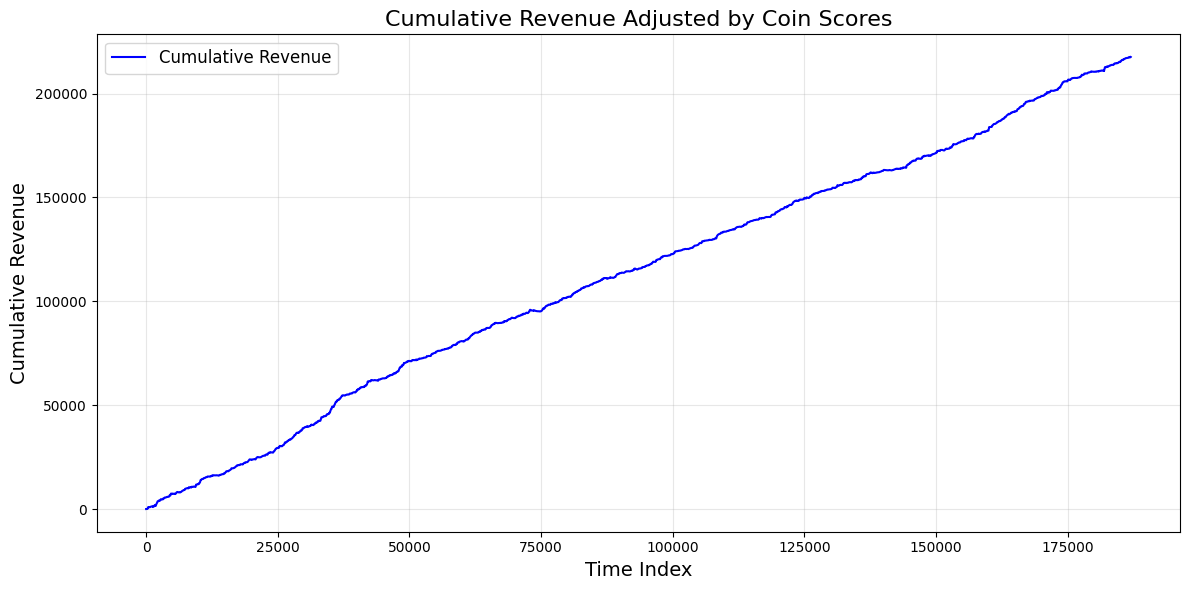

In [ ]:
import matplotlib.pyplot as plt

# 初始化每个 coin 的 score 为 0.5
coin_scores = {coin: 0.5 for coin in unique_coins}

# 初始化累积收益
cumulative_revenue = []
cb = 0
# 遍历 car_clean 数据按时间顺序
for _, row in car.iterrows():
  coin_1, coin_2 = row['coin_1'], row['coin_2']
  revenue = row['Each Revenue']
  # 计算当前行的收益，乘以两个 coin 的更小 score
  adjusted_revenue = revenue * min(coin_scores[coin_1], coin_scores[coin_2])
  cb+=1000* min(coin_scores[coin_1], coin_scores[coin_2])  
  # 更新 coin_1 和 coin_2 的 score
  if revenue > 0.5:
    coin_scores[coin_1] = min(coin_scores[coin_1] * 2, 1)
    coin_scores[coin_2] = min(coin_scores[coin_2] * 2, 1)
  elif revenue < -0.5:
    coin_scores[coin_1] = max(coin_scores[coin_1] * 0.9, 0.1)
    coin_scores[coin_2] = max(coin_scores[coin_1] * 0.9, 0.1)
  

  
  # 累加收益
  if cumulative_revenue:
    cumulative_revenue.append(cumulative_revenue[-1] + adjusted_revenue)
  else:
    cumulative_revenue.append(adjusted_revenue)

# 绘制累积收益图
plt.figure(figsize=(12, 6))
plt.plot(cumulative_revenue, label='Cumulative Revenue', color='blue')
plt.title('Cumulative Revenue Adjusted by Coin Scores', fontsize=16)
plt.xlabel('Time Index', fontsize=14)
plt.ylabel('Cumulative Revenue', fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
car

,Correlation,coin_1,coin_2,Difference,Each Revenue
0,0.591340,AVAXUSDT,AAVEUSDT,0.014762,0.000000
1,0.584608,AVAXUSDT,AAVEUSDT,0.014644,0.000000
2,0.589601,AVAXUSDT,AAVEUSDT,0.015283,0.000000
3,0.587264,AVAXUSDT,AAVEUSDT,0.015290,0.000000
4,0.588330,AVAXUSDT,AAVEUSDT,0.015054,0.000000
...,...,...,...,...,...
186996,0.489424,UNIUSDT,SEIUSDT,0.018972,4.135497
186997,0.485676,UNIUSDT,SEIUSDT,0.018412,4.139442
186998,0.479699,UNIUSDT,SEIUSDT,0.018089,4.734340
186999,0.471822,UNIUSDT,SEIUSDT,0.017876,3.470389
